Implementation of XOR Gate using Backpropagation in Neural
Networks.

In [1]:
import numpy as np
# Sigmoid activation function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivative of sigmoid
def sigmoid_derivative(x):
    return x * (1 - x)

In [2]:
# Input dataset (XOR)
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

# Output dataset
y = np.array([[0],
              [1],
              [1],
              [0]])

# Seed for reproducibility
np.random.seed(1)

In [3]:
# Initialize weights randomly
input_layer_neurons = 2
hidden_layer_neurons = 2
output_neurons = 1

In [4]:
# Weights
W1 = np.random.uniform(size=(input_layer_neurons, hidden_layer_neurons))
W2 = np.random.uniform(size=(hidden_layer_neurons, output_neurons))

# Bias
b1 = np.zeros((1, hidden_layer_neurons))
b2 = np.zeros((1, output_neurons))

In [5]:
epochs = 10000
learning_rate = 0.1

for epoch in range(epochs):

    # ---- Forward Propagation ----
    hidden_input = np.dot(X, W1) + b1
    hidden_output = sigmoid(hidden_input)

    final_input = np.dot(hidden_output, W2) + b2
    predicted_output = sigmoid(final_input)

    # ---- Backpropagation ----
    error = y - predicted_output

    d_output = error * sigmoid_derivative(predicted_output)

    error_hidden = d_output.dot(W2.T)
    d_hidden = error_hidden * sigmoid_derivative(hidden_output)

    # ---- Update Weights ----
    W2 += hidden_output.T.dot(d_output) * learning_rate
    W1 += X.T.dot(d_hidden) * learning_rate

    b2 += np.sum(d_output, axis=0, keepdims=True) * learning_rate
    b1 += np.sum(d_hidden, axis=0, keepdims=True) * learning_rate


In [6]:
# ---- Output ----
print("Final Output after training:")
print(predicted_output)

Final Output after training:
[[0.06624557]
 [0.93822756]
 [0.93836658]
 [0.06703146]]


To explore all major deep learning libraries, e.g., TensorFlow,
Keras, MXNet, JAX, and Hugging Face Transformers.

In [ ]:
import tensorflow as tf
from tensorflow import keras

# Load built-in dataset
(x_train, y_train), _ = keras.datasets.mnist.load_data()

# Normalize
x_train = x_train / 255.0

# Simple model
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train (just 1 epoch for demo)
model.fit(x_train, y_train, epochs=1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9148 - loss: 0.2996


In [ ]:
from keras.models import Sequential
from keras.layers import Dense
import numpy as np

# Dummy dataset (no real dataset needed)
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

model = Sequential()
model.add(Dense(4, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam')

model.fit(X, y, epochs=500, verbose=0)

print(model.predict(X))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
[[0.5203582 ]
 [0.5201404 ]
 [0.52029145]
 [0.4363712 ]]


In [ ]:
!pip install mxnet

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# XOR dataset
X = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
y = torch.tensor([[0.],[1.],[1.],[0.]])

# Model
model = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)

# Loss & optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

# Training
for epoch in range(1000):
    output = model(X)
    loss = criterion(output, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Output
print(model(X))

tensor([[5.0000e-01],
        [5.0000e-01],
        [9.9999e-01],
        [2.0098e-05]], grad_fn=<SigmoidBackward0>)


In [ ]:
import jax.numpy as jnp

# Simple tensor operations
x = jnp.array([1.0, 2.0, 3.0])

# Function
y = x ** 2 + 2*x

print(y)

[ 3.  8. 15.]


In [ ]:
from transformers import pipeline

# Load pretrained model
classifier = pipeline("sentiment-analysis")

# Test
result = classifier("This project is amazing!")
print(result)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9998857975006104}]


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving download.jpg to download.jpg


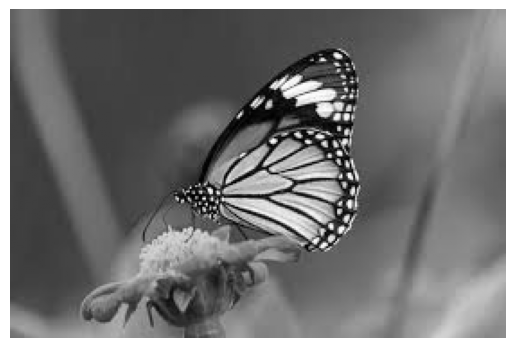

In [ ]:
import cv2
from matplotlib import pyplot as plt

img = cv2.imread("/content/download.jpg")

if img is None:
    print("Upload failed or wrong filename")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    plt.imshow(gray, cmap='gray')
    plt.axis('off')
    plt.show()

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import nltk
nltk.download('punkt')

from nltk.tokenize import word_tokenize

text = "AI is transforming the world!"

tokens = word_tokenize(text)
print(tokens)

['AI', 'is', 'transforming', 'the', 'world', '!']


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


To design and implement a Neural Network using Keras API.
a) To design a Neural Network using Keras api. b)To plot the
model and its subsequent layers(along with the input and output
dimensions of each layer) using vis_utils.

In [ ]:
pip install pydot graphviz

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(64, input_dim=10, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

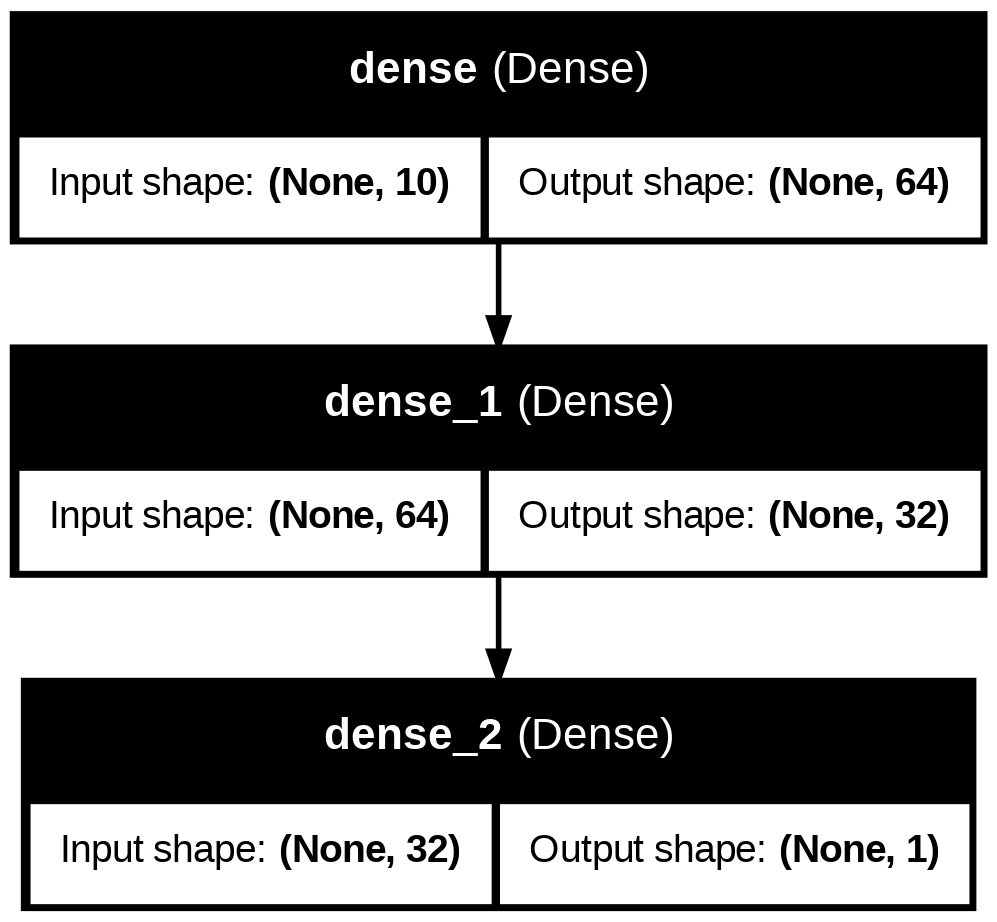

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

a) To design and implement a CNN for Multiclass Object
classification on image data.
b) Classification of digits from 0 to 9 using keras API and
training using layers of Conv2D, Maxpooling, Dropout etc.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize
x_train, x_test = x_train/255.0, x_test/255.0

# Reshape
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),   # extra layer
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),  # slightly different dropout

    layers.Dense(10, activation='softmax')
])

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(x_train, y_train, epochs=5,
                    validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.8040 - loss: 0.5377 - val_accuracy: 0.8660 - val_loss: 0.3590
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8753 - loss: 0.3444 - val_accuracy: 0.8846 - val_loss: 0.3103
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8941 - loss: 0.2940 - val_accuracy: 0.8984 - val_loss: 0.2756
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9066 - loss: 0.2620 - val_accuracy: 0.8985 - val_loss: 0.2851
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9145 - loss: 0.2372 - val_accuracy: 0.9018 - val_loss: 0.2709


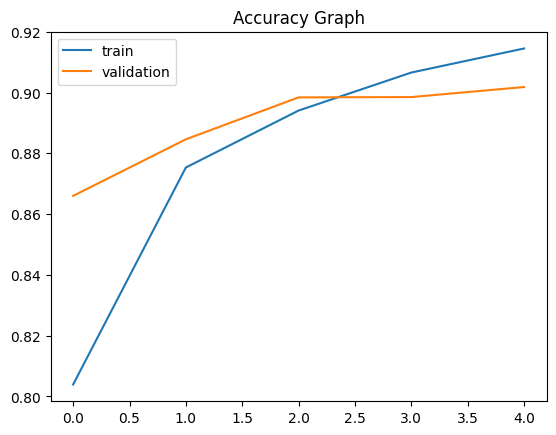

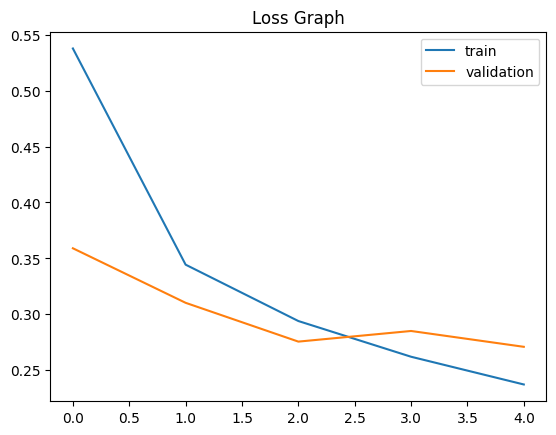

In [ ]:
# Accuracy
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.title("Accuracy Graph")
plt.legend()
plt.show()

# Loss
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.title("Loss Graph")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step


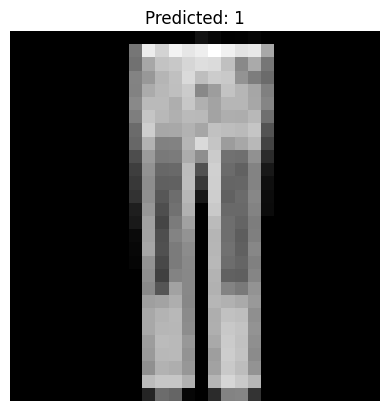

Actual: 1
Predicted: 1
Predicted label: Trouser


In [ ]:
index = 15
sample = x_test[index]

prediction = model.predict(sample.reshape(1,28,28,1))
predicted_class = np.argmax(prediction)

plt.imshow(sample.reshape(28,28), cmap='gray')
plt.title(f"Predicted: {predicted_class}")
plt.axis('off')
plt.show()

print("Actual:", y_test[index])
print("Predicted:", predicted_class)
labels = ['T-shirt','Trouser','Pullover','Dress','Coat',
          'Sandal','Shirt','Sneaker','Bag','Ankle boot']

print("Predicted label:", labels[predicted_class])

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize
x_train, x_test = x_train/255.0, x_test/255.0

# Reshape for CNN
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])


In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(x_train, y_train, epochs=5,
                    validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9381 - loss: 0.2077 - val_accuracy: 0.9850 - val_loss: 0.0512
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9741 - loss: 0.0903 - val_accuracy: 0.9875 - val_loss: 0.0422
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9790 - loss: 0.0764 - val_accuracy: 0.9888 - val_loss: 0.0373
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9835 - loss: 0.0577 - val_accuracy: 0.9886 - val_loss: 0.0366
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9846 - loss: 0.0528 - val_accuracy: 0.9912 - val_loss: 0.0298


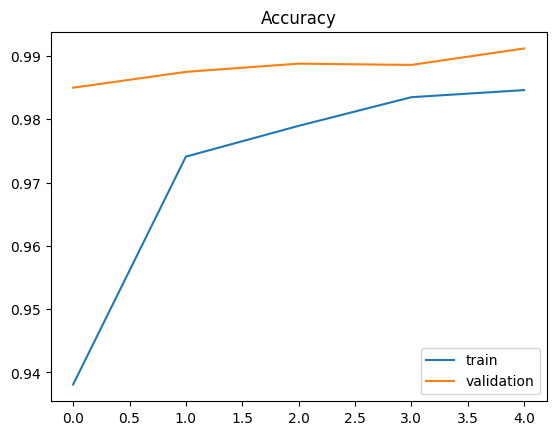

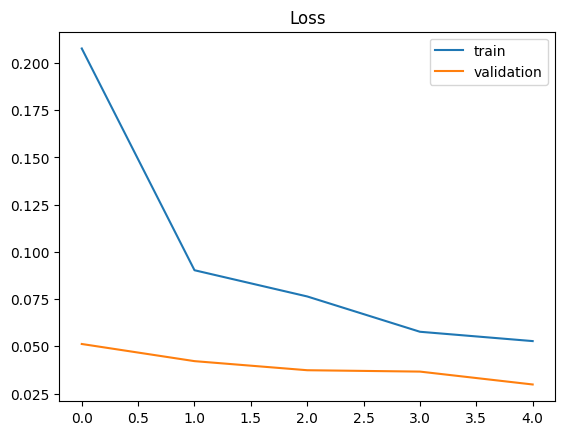

In [ ]:
# Accuracy graph
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.title("Accuracy")
plt.legend()
plt.show()

# Loss graph
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.title("Loss")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step


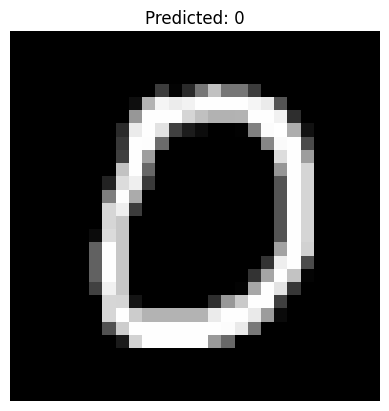

Actual: 0
Predicted: 0


In [ ]:
index = 10
sample = x_test[index]

prediction = model.predict(sample.reshape(1,28,28,1))
predicted_class = np.argmax(prediction)

plt.imshow(sample.reshape(28,28), cmap='gray')
plt.title(f"Predicted: {predicted_class}")
plt.axis('off')
plt.show()

print("Actual:", y_test[index])
print("Predicted:", predicted_class)

To design and implement simple RNN layer for Binary
Classification on text data.

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Load dataset (top 10,000 words)
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

# Pad sequences
x_train = pad_sequences(x_train, maxlen=200)
x_test = pad_sequences(x_test, maxlen=200)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
model = Sequential([
    Embedding(10000, 32, input_length=200),
    SimpleRNN(32),
    Dense(1, activation='sigmoid')
])
model.summary()
# Compile
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(x_train, y_train, epochs=3,
                    validation_data=(x_test, y_test))

Epoch 1/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.6521 - loss: 0.6117 - val_accuracy: 0.7245 - val_loss: 0.5434
Epoch 2/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.7846 - loss: 0.4695 - val_accuracy: 0.7830 - val_loss: 0.4910
Epoch 3/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.8692 - loss: 0.3153 - val_accuracy: 0.7944 - val_loss: 0.4791


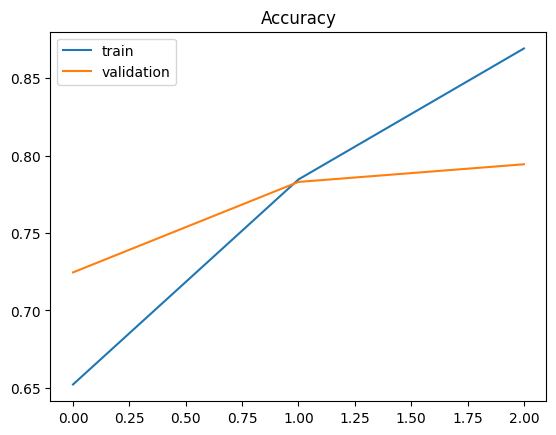

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.legend()
plt.title("Accuracy")
plt.show()

In [ ]:
import numpy as np

index = 5
sample = x_test[index]

prediction = model.predict(sample.reshape(1,200))
print("Predicted:", "Positive" if prediction > 0.5 else "Positive")
print("Actual:", "Positive" if y_test[index] == 1 else "Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted: Positive
Actual: Positive


a) To design and implement RNN(Recurrent Neural Network)
by using LSTM layer for Multiclass Classification on text data

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import reuters
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Load dataset (top 10,000 words)
(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=10000)

# Pad sequences
x_train = pad_sequences(x_train, maxlen=200)
x_test = pad_sequences(x_test, maxlen=200)

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step


In [ ]:
from tensorflow.keras.layers import Dropout

model = Sequential([
    Embedding(10000, 64),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dropout(0.5),
    Dense(46, activation='softmax')
])


In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(x_train, y_train, epochs=5,
                    validation_data=(x_test, y_test))

Epoch 1/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.3219 - loss: 2.6747 - val_accuracy: 0.4746 - val_loss: 2.2245
Epoch 2/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.4930 - loss: 2.0175 - val_accuracy: 0.5472 - val_loss: 1.7771
Epoch 3/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.5210 - loss: 1.8539 - val_accuracy: 0.5396 - val_loss: 1.8155
Epoch 4/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.5605 - loss: 1.7417 - val_accuracy: 0.5739 - val_loss: 1.6942
Epoch 5/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.5811 - loss: 1.6064 - val_accuracy: 0.5481 - val_loss: 1.6915


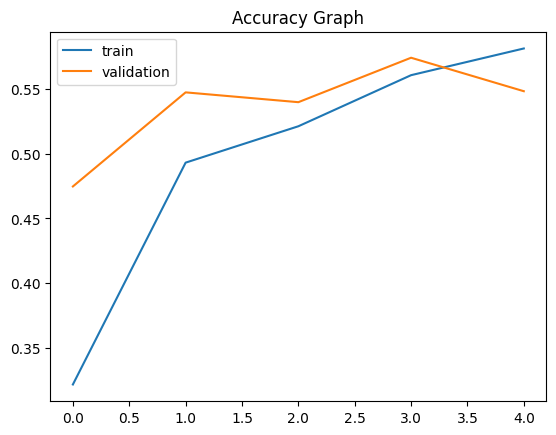

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

In [ ]:
import numpy as np

index = 10
sample = x_test[index]

prediction = model.predict(sample.reshape(1,200))
predicted_class = np.argmax(prediction)

print("Predicted Class:", predicted_class)
print("Actual Class:", y_test[index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
Predicted Class: 1
Actual Class: 5


b) To design and implement a RNN(Recurrent Neural Network)
by using GRU layer for Multiclass Classification on text data.

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import reuters
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=10000)

# Pad sequences
x_train = pad_sequences(x_train, maxlen=200)
x_test = pad_sequences(x_test, maxlen=200)


In [ ]:
model = Sequential([
    Embedding(10000, 64, input_length=200),
    GRU(64),
    Dropout(0.5),
    Dense(46, activation='softmax')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(x_train, y_train, epochs=5,
                    validation_data=(x_test, y_test))

Epoch 1/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.3952 - loss: 2.2960 - val_accuracy: 0.4501 - val_loss: 1.8686
Epoch 2/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5401 - loss: 1.8130 - val_accuracy: 0.5668 - val_loss: 1.7465
Epoch 3/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5842 - loss: 1.6402 - val_accuracy: 0.5735 - val_loss: 1.6692
Epoch 4/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6000 - loss: 1.5404 - val_accuracy: 0.5882 - val_loss: 1.6382
Epoch 5/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.6167 - loss: 1.5056 - val_accuracy: 0.5761 - val_loss: 1.6637


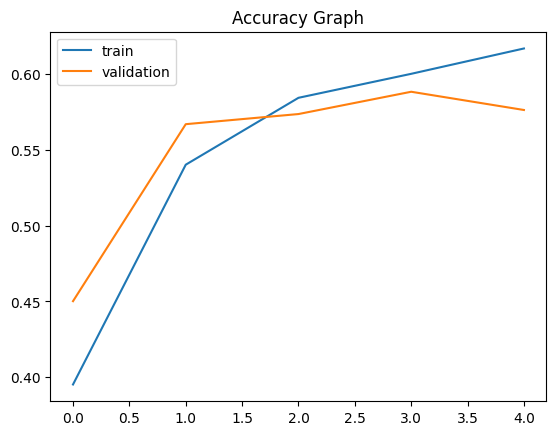

In [ ]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

In [ ]:
index = 20

prediction = model.predict(x_test[index].reshape(1,200))
predicted_class = np.argmax(prediction)

print("Predicted:", predicted_class)
print("Actual:", y_test[index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
Predicted: 19
Actual: 8


Implement Generative Adversarial network

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
(x_train, _), _ = tf.keras.datasets.mnist.load_data()
x_train = x_train / 127.5 - 1.0  # normalize to [-1,1]
x_train = x_train.reshape(-1, 28, 28, 1)

BUFFER_SIZE = 60000
BATCH_SIZE = 256

dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

In [ ]:
# Generator
def build_generator():
    model = tf.keras.Sequential([
        layers.Dense(128, activation='relu', input_dim=100),
        layers.Dense(256, activation='relu'),
        layers.Dense(28*28*1, activation='tanh'),
        layers.Reshape((28,28,1))
    ])
    return model

# Discriminator
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Flatten(input_shape=(28,28,1)),
        layers.Dense(256, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model


In [ ]:
generator = build_generator()
discriminator = build_discriminator()

discriminator.compile(loss='binary_crossentropy',
                      optimizer='adam',
                      metrics=['accuracy'])

# Combine GAN
discriminator.trainable = False

gan = tf.keras.Sequential([generator, discriminator])
gan.compile(loss='binary_crossentropy', optimizer='adam')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
d_losses = []
g_losses = []

In [ ]:
EPOCHS = 3
noise_dim = 100

for epoch in range(EPOCHS):
    for real_images in dataset:
        batch_size = real_images.shape[0]

        # Generate fake images
        noise = np.random.normal(0,1,(batch_size, noise_dim))
        fake_images = generator.predict(noise, verbose=0)

        # Labels
        real_labels = np.ones((batch_size,1))
        fake_labels = np.zeros((batch_size,1))

        # ---- Train Discriminator ----
        discriminator.trainable = True

        d_loss_real = discriminator.train_on_batch(real_images, real_labels)
        d_loss_fake = discriminator.train_on_batch(fake_images, fake_labels)

        # Average discriminator loss
        d_loss = 0.5 * (d_loss_real[0] + d_loss_fake[0])

        # ---- Train Generator ----
        noise = np.random.normal(0,1,(batch_size, noise_dim))
        misleading_labels = np.ones((batch_size,1))

        discriminator.trainable = False
        g_loss = gan.train_on_batch(noise, misleading_labels)

        # Store losses
        d_losses.append(d_loss)
        g_losses.append(g_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} completed | D Loss: {d_loss:.4f} | G Loss: {g_loss:.4f}")

Epoch 1/3 completed | D Loss: 0.0604 | G Loss: 5.1406
Epoch 2/3 completed | D Loss: 0.0596 | G Loss: 5.4932
Epoch 3/3 completed | D Loss: 0.0610 | G Loss: 5.5860


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step


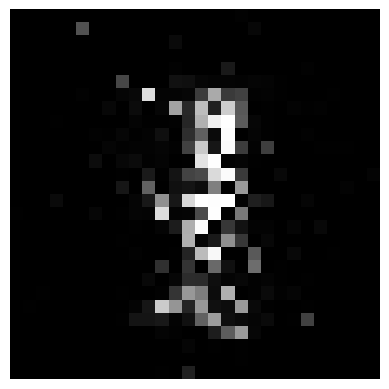

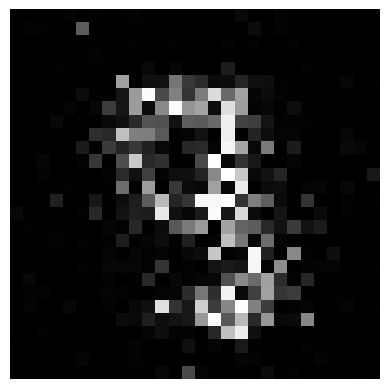

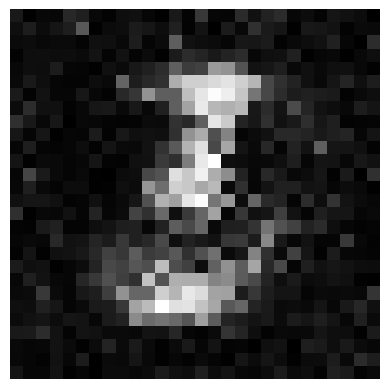

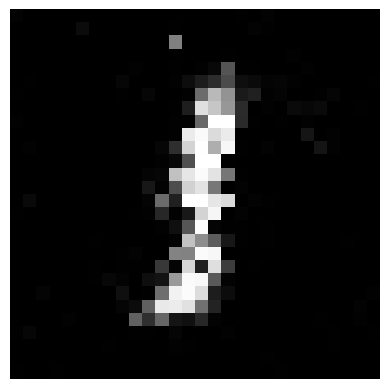

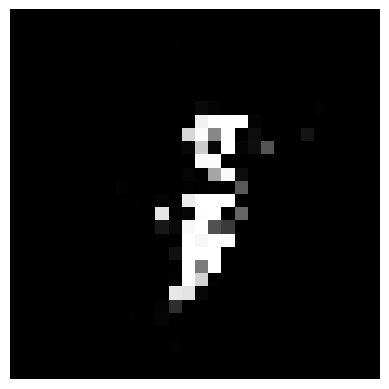

In [ ]:
noise = np.random.normal(0,1,(5,100))
generated_images = generator.predict(noise)

for i in range(5):
    plt.imshow(generated_images[i].reshape(28,28), cmap='gray')
    plt.axis('off')
    plt.show()

Implement a Transformer-based text classification model to
automatically categorize news articles into predefined topics
such as politics, sports, technology, and business.

In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification
from datasets import load_dataset
import torch

# Load dataset
dataset = load_dataset("ag_news")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [ ]:
print(dataset['train'][0])

{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


In [ ]:
labels = ["World", "Sports", "Business", "Sci/Tech"]

In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize(example):
    return tokenizer(example['text'], padding='max_length', truncation=True)

dataset = dataset.map(tokenize, batched=True)

# Convert to PyTorch
dataset.set_format(type='torch', columns=['input_ids','attention_mask','label'])

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [ ]:
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=4)

# Sample batch
batch = dataset['train'][:8]

outputs = model(input_ids=batch['input_ids'],
                attention_mask=batch['attention_mask'],
                labels=batch['label'])


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
loss = outputs.loss
print("Loss:", loss.item())

Loss: 1.4946380853652954


In [ ]:
text = ["The team won the championship"]

inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)

outputs = model(**inputs)
pred = torch.argmax(outputs.logits, dim=1)

print("Predicted:", labels[pred.item()])

Predicted: Sports
